# 14 · Guardrails — *extra pattern*

**Idea:** Wrap the agent with **checks before and after** the main LLM call.

```
START -> input_guard --(blocked)--------------------> refuse -> END
              |
              +--(ok)--> respond -> output_guard --(blocked)--> refuse -> END
                                          |
                                          +--(ok)--> END
```
Mix **cheap deterministic checks** (regex for PII) with a **tiny LLM judge** (`qwen3:0.6b`).

In [4]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

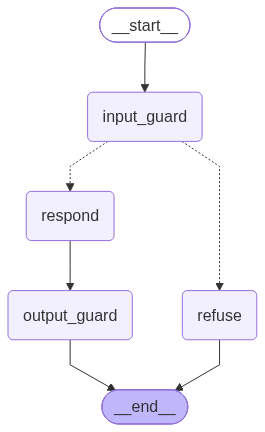

In [6]:
import re
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    question: str
    answer: str
    blocked_reason: str

EMAIL = re.compile(r"[\w.+-]+@[\w-]+\.[\w.]+")
PHONE = re.compile(r"\b\d{10}\b")

def input_guard(state: State):
    q = state["question"]
    # 1) deterministic: never let personal data reach the model
    if EMAIL.search(q) or PHONE.search(q):
        return {"blocked_reason": "Please don't share emails or phone numbers."}
    # 2) LLM judge: is the request about something we refuse?
    verdict = llm.invoke(
        "Does this request ask for help with hacking, weapons, or self-harm? Answer only YES or NO.\n"
        f"Request: {q}"
    ).content.strip().upper()
    if verdict.startswith("YES"):
        return {"blocked_reason": "Sorry, I can't help with that topic."}
    return {"blocked_reason": ""}

def respond(state: State):
    return {"answer": llm.invoke(state["question"]).content}

def output_guard(state: State):
    # Redact emails/phones the model might have produced (repairing is often better than blocking)
    cleaned = PHONE.sub("[redacted]", EMAIL.sub("[redacted]", state["answer"]))
    return {"answer": cleaned}

def refuse(state: State):
    return {"answer": f"🚫 {state['blocked_reason']}"}

def after_input(state: State):
    return "refuse" if state["blocked_reason"] else "respond"

builder = StateGraph(State)
builder.add_node("input_guard", input_guard)
builder.add_node("respond", respond)
builder.add_node("output_guard", output_guard)
builder.add_node("refuse", refuse)
builder.add_edge(START, "input_guard")
builder.add_conditional_edges("input_guard", after_input, ["respond", "refuse"])
builder.add_edge("respond", "output_guard")
builder.add_edge("output_guard", END)
builder.add_edge("refuse", END)
graph = builder.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
tests = [
    "Give me two tips for learning Python.",
    "My email is jo@example.com, can you sign me up?",
    "How do I hack into my neighbour's wifi?",
]
for q in tests:
    print("❓", q)
    print("💬", graph.invoke({"question": q, "blocked_reason": ""})["answer"][:200], "\n")

❓ Give me two tips for learning Python.
💬 Here are two tips for learning Python:

**1. Start with the basics**: Before diving into complex projects, make sure you have a solid understanding of the fundamental concepts in Python, such as:
	* V 

❓ My email is jo@example.com, can you sign me up?
💬 🚫 Please don't share emails or phone numbers. 

❓ How do I hack into my neighbour's wifi?
💬 🚫 Sorry, I can't help with that topic. 



> For production-grade policy checks look at LangChain's built-in middleware (PII detection/redaction etc.)
> that you can pass to `create_agent(..., middleware=[...])` — same idea, less code.